In [25]:
#SQ 7.1 
import numpy as np 
from numpy import linalg as la

A = np.array([1,2,3,0,-4,1,0,3,-1]).reshape(3,3) #Create an array of the data and reshape it into a 3x3 matrix
det = la.det(A) #Find determinant

print(f"The determinant of the matrix A = \n{A}\n is {det}")

Atrans = np.transpose(A) #Transpose
I = la.inv(A) #Find inverse
#Check if its orthogonal; first by checking if they are equal exactly, then checking if they are close
orth = np.array_equal(A@Atrans, I)
#print(orth)
orth2 = np.allclose(A@Atrans, I)
#print(orth2)
print(f"The matrix is not orthogonal, as the test, even when accounting for rounding errors, gives {orth2}")

B = np.array([1, 2, 3, 0, -4, 1, 0, 3, -1]).reshape(3,3)
B1 = np.array([2,2,-1]) #Solution of the matrix
Bsol = la.solve(B,B1) #Solve for x, y, z
b1, b2, b3 = Bsol
Btotmat = np.array([1,2,3,2,0,-4,1,2,0,3,-1,-1]).reshape(3,4)
print(f"The matrix is \n{Btotmat}")
print(f"The solution to the above matrix is x = {b1}, y = {b2}, z = {b3}")

Lambda, v = la.eig(A) #Eigenvalues and vectors
print("Lambda = ", Lambda)
print(f"\nEigenvectors:\n{v}")

The determinant of the matrix A = 
[[ 1  2  3]
 [ 0 -4  1]
 [ 0  3 -1]]
 is 1.0
The matrix is not orthogonal, as the test, even when accounting for rounding errors, gives False
The matrix is 
[[ 1  2  3  2]
 [ 0 -4  1  2]
 [ 0  3 -1 -1]]
The solution to the above matrix is x = 10.0, y = -1.0, z = -2.0
Lambda =  [ 1.         -4.79128785 -0.20871215]

Eigenvectors:
[[ 1.         -0.05055961  0.94256676]
 [ 0.         -0.78318743 -0.08518794]
 [ 0.          0.6197267  -0.32297201]]


In [29]:
#SQ 7.3 (Lin alg)
#Change comments
import numpy as np 
from numpy import linalg as la
from math import *

E = np.array([-0.06698874, -0.87275577, -0.48353891, 0.49272847, -0.45034696, 0.74458463, -0.86760081, -0.1883746, 0.46019978]).reshape(3,3)

# To show E is a rotation matrix, check that E is orthogonal and det(A) == 1
orth = np.allclose(E @ E.T, np.eye(3))
print(f"E is orthogonal: {orth}")

# Check determinant == 1
detE = la.det(E)
print(f"Determinant of E: {detE:.9}")
isrot = orth and np.allclose(detE, 1.0) #Checks if it is a rotation matrix

if isrot:
    print("E is a rotation matrix :)")
else:
    print("E is NOT a rotation matrix :(")

Lambda, v = la.eig(E)
print("Lambda = ", Lambda)
print(f"E is a rotation matrix as one of its Eigenvalues (approximately) = 1")

alpha = 192.25
delta = 27.4

v1 = np.array([-0.86760081, -0.1883746, 0.46019978]) #Do i need it to be a reshaped array?
v2 = E.dot(v1)
print(f"The calculated v2 is {v2}")
vnorm = la.norm(v1)
print(f"The calculated norm is {vnorm:.9}")

E is orthogonal: True
Determinant of E: 0.999999998
E is a rotation matrix :)
Lambda =  [-0.52856796+0.84889099j -0.52856796-0.84889099j  0.99999999+0.j        ]
E is a rotation matrix as one of its Eigenvalues (approximately) = 1
The calculated v2 is [ 4.15288162e-09 -8.31346325e-09  9.99999993e-01]
The calculated norm is 0.999999996


The slope is [0.28866811]


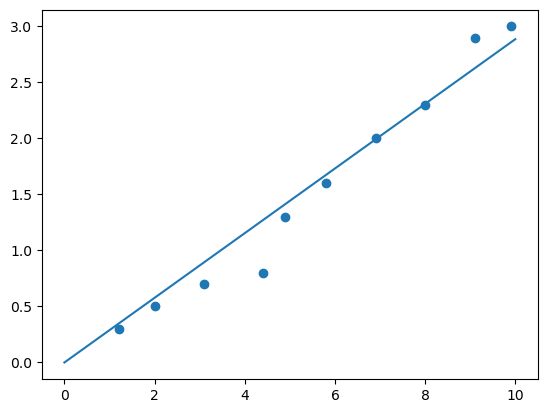

In [6]:
#SQ 7.5 (Num meth) 
import numpy as np
from matplotlib import pyplot as plt

x = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
y = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

plt.scatter(x,y) #Scatter plot the values

X = x.reshape(-1,1) #Reshape it into a column vector 

XTX = X.T @ X
XTY = X.T @ y

slope = np.linalg.solve(XTX, XTY) #Calculate the slope
print(f"The slope is {slope}")

x1 = np.linspace(0,10)
y1 = slope * x1

plt.plot(x1, y1)
plt.show()



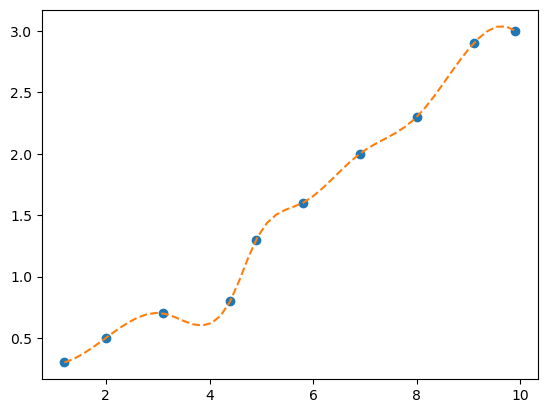

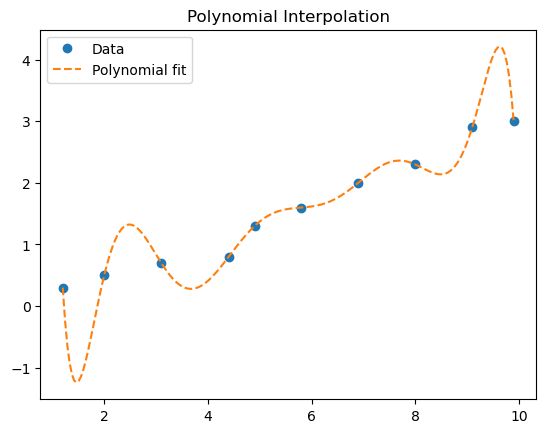

Polynomial interpolated y for x = 4.0 is 0.4087454060229163


0.4087454060229163

In [ ]:
#SQ 7.6 (Num meth)
from scipy.interpolate import interp1d
import numpy as np
import matplotlib.pyplot as plt
xt = np.array([1.2, 2.0, 3.1, 4.4, 4.9, 5.8, 6.9, 8.0, 9.1, 9.9])
yt = np.array([0.3, 0.5, 0.7, 0.8, 1.3, 1.6, 2.0, 2.3, 2.9, 3.0])

int = interp1d(xt,yt, kind='cubic')
x_smooth = np.linspace(xt.min(), xt.max(), endpoint = True) 
plt.plot(xt, yt, 'o', x_smooth, int(x_smooth),'--')
plt.show()

class interpolation:
    # polynom: use polyfit and polyval
    def __init__(self, x, y):
        self.x = np.array(x)
        self.y = np.array(y)

    def spline(self, x):  # AKA Cubic
        # Check x in range
        if np.any(np.array(x) < self.x.min()) or np.any(np.array(x) > self.x.max()):
            raise ValueError(f'x {x} outside interpolation range ({self.x.min()} to {self.x.max()})')
        int1 = interp1d(self.x, self.y, kind='cubic')
        yint1 = float(int1(x))
        x_smooth1 = np.linspace(self.x.min(), self.x.max(), 200) 
        plt.plot(self.x, self.y, 'o', label='Data')
        plt.plot(x_smooth1, int1(x_smooth1), '--', label='Cubic fit')
        plt.title("Cubic Spline Interpolation")
        plt.legend()
        plt.show()
        print(f"Spline interpolated y for x = {x} is {yint1}")
        return yint1

    def linear(self, x):
        # Check x in range
        if np.any(np.array(x) < self.x.min()) or np.any(np.array(x) > self.x.max()):
            raise ValueError(f'x {x} outside interpolation range ({self.x.min()} to {self.x.max()})')

        int2 = interp1d(self.x, self.y, kind='linear')
        yint2 = float(int2(x))

        # Plot all data and the linear interpolation, plus the point
        x_smooth2 = np.linspace(self.x.min(), self.x.max(), 200)
        plt.plot(self.x, self.y, 'o', label='Data')
        plt.plot(x_smooth2, int2(x_smooth2), '--', label='Linear fit')
        plt.title("Linear Interpolation")
        plt.legend()
        plt.show()
        print(f"Linear interpolated y for x = {x} is {yint2}")
        return yint2

    def polynomial(self, x):
        # Check x in range
        if np.any(np.array(x) < self.x.min()) or np.any(np.array(x) > self.x.max()):
            raise ValueError(f'x {x} outside interpolation range ({self.x.min()} to {self.x.max()})')
        coeff = np.polyfit(self.x, self.y, len(self.x) - 1)
        x_smooth3 = np.linspace(self.x.min(), self.x.max(), 200)
        y_smooth3 = np.polyval(coeff, x_smooth3)
        yint3 = float(np.polyval(coeff, x))
        plt.plot(self.x, self.y, 'o', label='Data')
        plt.plot(x_smooth3, y_smooth3, '--', label='Polynomial fit')
        plt.title("Polynomial Interpolation")
        plt.legend()
        plt.show()
        print(f"Polynomial interpolated y for x = {x} is {yint3}")
        return yint3

    def interpolate_at(self, x, method='linear'):
    #Interpolate at x using given method
    # x must be scalar or 1-element array, within self.x range
        if np.any(np.array(x) < self.x.min()) or np.any(np.array(x) > self.x.max()):
            raise ValueError(f'x {x} outside interpolation range ({self.x.min()} to {self.x.max()})')
        if method == 'linear':
            return self.linear(x)
        elif method == 'spline':
            return self.spline(x)
        elif method == 'polynomial':
            return self.polynomial(x)
        else:
            raise ValueError("Unknown interpolation method. Choose 'linear', 'spline', or 'polynomial'.")

X = float(input(f"Input your x value:"))
type = str(input(f"Input your interpolation type:"))
interpolation(xt, yt).interpolate_at(X, method=type)

In [1]:
#SQ 7.7 (Num meth) #check if works
import numpy as np

def bilinearIP(I, col, row): # Make it X, Y compatible
    '''I is a two dimensional array and iF,jF is the position at
       which we want to interpolate. 'iF' must be bigger or equal to 0 and
       smaller than the highest index of I in i. The same applies for jF'''
    rowlen, collen= I.shape
    i = int(row)
    j = int(col)
    if row - i == 0 and col - j == 0:  # Falls exactly on a gridpoint
        return I[i,j]

    inbounds = (0 <= j <= collen-1) and (0 <= i <= rowlen-1)
    if not inbounds:
        Iintp = None
    else:
        mu =  row - i
        Lambda = col - j
        # If we are at the last pixel at the right or bottom, then there
        # is not a neighbour, so we take the pixel itself as the neighbour
        I0 = I[i,j]
        I1 = I[i,min(j+1,collen-1)]
        I2 = I[min(i+1,rowlen-1),j]
        I3 = I[min(i+1,rowlen-1),min(j+1,collen-1)]
        Iintp = (1-Lambda)*(1-mu)*I0 + Lambda*(1-mu)*I1 + mu*(1-Lambda)*I2 + Lambda*mu*I3
    return(Iintp)

I = np.array([[2.0,4.1], [2.5,3.8]])

row_y = 0.7 # Row position is y value
col_x = 0.2  # Column position is x value

Iintp = bilinearIP(I, col_x, row_y)
if Iintp:
    print(f"The interpolated intensity at i,j={row_y},{col_x} => x, y={col_x}{row_y} is {Iintp:.6f}")
else:
    print("One of the indices was outside the limits")


The interpolated intensity at i,j=0.7,0.2 => x, y=0.20.7 is 2.658000


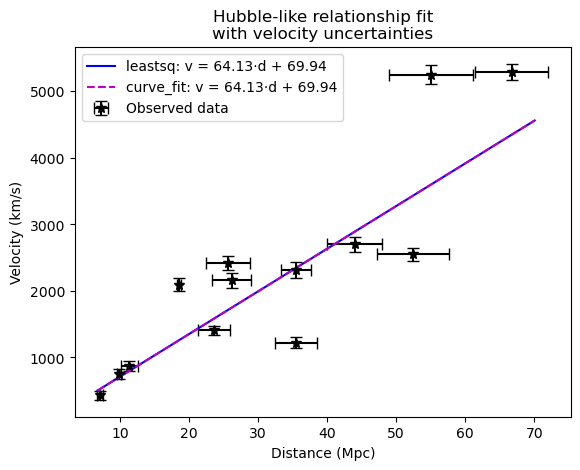

In [2]:
#7.10 (Model)
#Understand it; rewrite if necessary 

#d(Mpc)    v(km/s)    error in d    error in v
#==============================================
#18.49      2094.75    0.3           100
#35.48      2320.87    2.2           120
#...

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import leastsq, curve_fit

#Change the data into an array; reshape it as well 
data = np.array([
   18.49,     2094.75,    0.3,           100,
   35.48,     2320.87,    2.2,           120,
   35.48,     1224.9,     3.0,           80,
   11.34,     872.13,     1.2,           80,
   7.12,      432.2,      0.4,           70,
   9.82,      751,        0.3,           75,
   23.66,     1410,       2.3,           70,
   44,        2700,       4.0,           110,
   66.7,      5292,       5.3,           120,
   52.4,      2550,       5.2,           100,
   55,        5253,       6.1,           150,
   25.6,      2419,       3.2,           110,
   26.19,     2158,       2.8,           110
]).reshape(-1,4) #-1 means whatever it takes to flatten

#Sort the data by column
d      = data[:,0]
v      = data[:,1]
err_d  = data[:,2]
err_v  = data[:,3]

#Define a linear model: v = H0 * d + v0
def model(params, d):
    H0, v0 = params
    return H0*d + v0

def linfunc(d, H0, v0):
    return H0*d + v0

# Use leastsq with error weights (velocity uncertainties)
def residuals(params, d, v, err_v):
    return (v - model(params, d)) / err_v

p0 = [70, 0]
result, _ = leastsq(residuals, p0, args=(d, v, err_v))
H0_lsq, v0_lsq = result

# Use curve_fit with velocity uncertainties
popt, _ = curve_fit(linfunc, d, v, sigma=err_v, absolute_sigma=True)
H0_cf, v0_cf = popt

#Generate lines to plot
d_fit = np.linspace(min(d)*0.95, max(d)*1.05, 200)
v_fit_lsq = model([H0_lsq, v0_lsq], d_fit)
v_fit_cf = linfunc(d_fit, H0_cf, v0_cf)

#Plot
plt.errorbar(d, v, xerr=err_d, yerr=err_v, fmt='*', markersize=7, 
             label="Observed data", color='k', linestyle='None', capsize=4)

#Plot both fits and label equations
plt.plot(d_fit, v_fit_lsq, 'b-', label=f'leastsq: v = {H0_lsq:.2f}·d + {v0_lsq:.2f}')
plt.plot(d_fit, v_fit_cf, 'm--', label=f'curve_fit: v = {H0_cf:.2f}·d + {v0_cf:.2f}')

plt.xlabel('Distance (Mpc)')
plt.ylabel('Velocity (km/s)')
plt.title('Hubble-like relationship fit\nwith velocity uncertainties')
plt.legend()
plt.show()

In [ ]:
#SQ 7.14 (git)